  # ASETS-II cases simulation

  This is an example of a simulation package for conjugate heat transfer of an
  oscillating heat pipe. SI units are used and units are emitted

  ### What do we need to solve an OHP problem?

  **specify properties** : Solid property, Fluid property

  **set the geometries** : Computational domain, Heaters/Condensers, OHP shapes

  **construct the systems** : Fluid system(1D), HeatConduction system(2D)

  **initialize** : initialize the integrators and the data structs for saving

  **solve** : time marching to solve the two weakly coupled integrators
  alternately

  **save/examine** : save the data for post-processing

  # Packages

Load the OHP package and plotting/progress utilities used throughout the notebook.

In [1]:
using OscillatingHeatPipe # our main package
using Plots # for plotting
using ProgressMeter # to have a progress bar in the calculation

  # Specify properties

  ### Solid Physical parameters

Define aluminum plate material properties and compute the thermal diffusivity used by the immersed-layer heat-conduction model.

In [2]:
ρₛ = 2730; # material density [kg/m^3]
cₛ  = 8.93e02; # material specific heat [J/kg K]
kₛ  = 1.93e02; # material heat conductivity
αₛ = kₛ/ρₛ/cₛ

dₛ = 1.5e-3; # effective d (The thickness of an ideal uniform thickness plate occupying the same volume)

  ### Fluid Physical parameters

Set the reference temperature, choose the working fluid, and construct the saturation-property helper for the tube model.

In [3]:
Tref = 291.2 # reference temperature
fluid_type = "Butane"
p_fluid = SaturationFluidProperty(fluid_type,Tref) # This function relies on CoolProp.jl package

Saturation properties for Butane at constant temperature 291.2 [K]


  # Set the geometries

  ### Geometry parameters

Choose the plate dimensions, grid spacing, computational limits, and create the physical grid for the two-dimensional solid domain.

In [4]:
Δx = 0.0006 # [m]

Lx = 0.1524; # plate size x [m]
Ly = 0.0648; # plate size y [m]
xlim = (-Lx/2,Lx/2) # plate x limits
ylim = (-Ly/2,Ly/2) # plate y limits

g = PhysicalGrid(1.1 .* xlim,1.1 .* ylim,Δx); # build a gird slightly larger than the plate

## set physical parameters

Set a local inch-to-meter conversion and the heater power used by both the plate and tube models.

In [5]:
inches=2.54e-2
power = 40 # Watt

40

Collect the physical parameters passed into the heat-conduction system, including diffusivity, heat-flux scaling, heater settings, and the OHP line-source placeholder.

In [6]:
phys_params = Dict( "diffusivity"              => αₛ,
                    "flux_correction"          => ρₛ*cₛ*dₛ,
                    "Fourier"                  => 1.0,
                    "ohp_flux"                 => [NaN], # initial value, the value here is useless
                    "areaheater_power"         => power, # total power
                    "areaheater_area"          => 2inches*2inches, # total area
                    "areaheater_temp"          => 0.0,   # relative temperature compared with "background temperature"
                    "areaheater_coeff"         => 2300.0,
                    "background temperature"   => Tref
                     )

Dict{String, Any} with 9 entries:
  "areaheater_coeff"       => 2300.0
  "Fourier"                => 1.0
  "flux_correction"        => 3656.84
  "ohp_flux"               => [NaN]
  "diffusivity"            => 7.91668e-5
  "areaheater_area"        => 0.00258064
  "areaheater_power"       => 40
  "areaheater_temp"        => 0.0
  "background temperature" => 291.2

## Boundary conditions

Build the polygonal plate boundary for the immersed-layer geometry, including condenser cutouts and boundary point spacing.

In [7]:
Δs = 1.4*cellsize(g)

trim = 0.006
cond_block = 1.1inches
xbound = [ -Lx/2,-Lx/2, -Lx/2+cond_block,-Lx/2+cond_block, Lx/2-cond_block,  Lx/2-cond_block,
            Lx/2, Lx/2,  Lx/2-cond_block, Lx/2-cond_block,-Lx/2+cond_block, -Lx/2+cond_block];
ybound = [  Ly/2,-Ly/2, -Ly/2,           -Ly/2+trim,      -Ly/2+trim,       -Ly/2,
           -Ly/2, Ly/2,  Ly/2,            Ly/2-trim ,      Ly/2-trim,        Ly/2 ];
body = Polygon(xbound,ybound,Δs)

Closed polygon with 12 vertices and 544 points
   Current position: (0.0,0.0)
   Current angle (rad): 0.0


Create a stationary rigid-body motion object for the plate boundary and update the body coordinates in that reference frame.

In [8]:
X = MotionTransform([0,0],0)
joint = Joint(X)
m = RigidBodyMotion(joint,body)
x = zero_motion_state(body,m)
update_body!(body,x,m)

Closed polygon with 12 vertices and 544 points
   Current position: (0.0,0.0)
   Current angle (rad): 0.0


Plot the immersed plate boundary so the computational geometry can be checked before adding heaters, condensers, and the tube path.

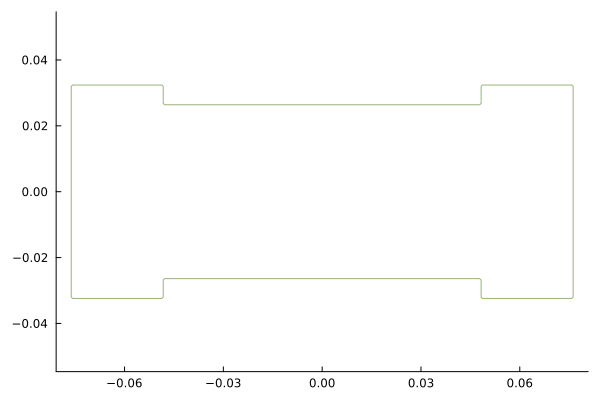

In [9]:
plot(body,fillalpha=0)

Define zero-flux boundary-condition functions for the exterior and interior immersed boundaries and store them in the boundary-condition dictionary.

In [10]:
function get_qbplus(t,x,base_cache,phys_params,motions)
    nrm = normals(base_cache)
    qbplus = zeros_surface(base_cache)
    return qbplus
end

function get_qbminus(t,x,base_cache,phys_params,motions)
    nrm = normals(base_cache)
    qbminus = zeros_surface(base_cache)
    return qbminus
end

bcdict = Dict("exterior" => get_qbplus,"interior" => get_qbminus)

Dict{String, Function} with 2 entries:
  "interior" => get_qbminus
  "exterior" => get_qbplus

  ### Set up the evaporators and condensers

  Right now, the OHPtype looks up a preset dictionary of OHP evaporators and
  condensers.

Define the area-source models for heater input and condenser cooling using the physical parameters dictionary.

In [11]:
function heatermodel!(σ,T,t,fr::AreaRegionCache,phys_params)
    σ .= phys_params["areaheater_power"] / phys_params["areaheater_area"] / phys_params["flux_correction"]
end


function condensermodel!(σ,T,t,fr::AreaRegionCache,phys_params)
    T0 = phys_params["areaheater_temp"]
    h = phys_params["areaheater_coeff"]
    corr = phys_params["flux_correction"]

    σ .= h*(T0 - T) / corr
end

condensermodel! (generic function with 1 method)

Create two heater regions, position them on the plate, and wrap them as area forcing models.

In [12]:
fregion1_h = Rectangle(0.5inches,1.0inches,1.4*Δx)
fregion2_h = deepcopy(fregion1_h)
tr1_h = RigidTransform((0.7inches,-0.0),0.0)
tr2_h = RigidTransform((-0.7inches,-0.0),0.0)

heater1 = AreaForcingModel(fregion1_h,tr1_h,heatermodel!);
heater2 = AreaForcingModel(fregion2_h,tr2_h,heatermodel!);

Create two condenser regions, position them on the plate, and wrap them as area forcing models.

In [13]:
fregion1_c = Rectangle(0.5inches,0.0648*0.95/2,1.4*Δx)
fregion2_c = deepcopy(fregion1_c)
tr1_c = RigidTransform((2.45inches,-0.0),0.0)
tr2_c = RigidTransform((-2.45inches,-0.0),0.0)

cond1 = AreaForcingModel(fregion1_c,tr1_c,condensermodel!);
cond2 = AreaForcingModel(fregion2_c,tr2_c,condensermodel!);

  ### Set up OHP channel's shape

  constructohpcurve is a built-in function that generates two arrays: x that
  contains all x values of the discrete points, and y contains all y values. x
  and y have the same length.

Construct the ASETS OHP centerline, build the line-source model, and attach the heat-flux callback used to couple tube heat transfer into the plate.

In [14]:
x, y = construct_ohp_curve("ASETS",Δx) # get x and y coordinates for the channel
ohp = BasicBody(x,y) # build a BasicBody based on x,y

tr_ohp = RigidTransform((0.0,0.0),0.0)

function ohpmodel!(σ,T,t,fr::LineRegionCache,phys_params)
    σ .= phys_params["ohp_flux"] ./ phys_params["flux_correction"]
end
ohp_linesource = LineForcingModel(ohp,tr_ohp,ohpmodel!);

  ### Plot what you got so far

Plot the full geometry with plate, heaters, condensers, and OHP channel to visually verify the setup.

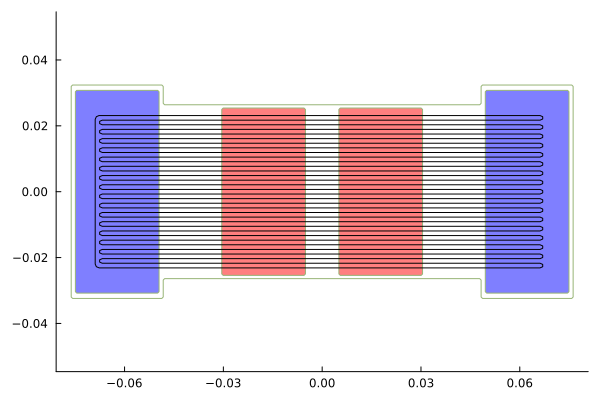

In [15]:
plot(body,fillalpha=0)
update_body!(fregion1_h,tr1_h)
update_body!(fregion1_c,tr1_c)
update_body!(fregion2_h,tr2_h)
update_body!(fregion2_c,tr2_c)

plot!(fregion1_h,fillcolor=:red,fillalpha=0.5)
plot!(fregion1_c,fillcolor=:blue,fillalpha=0.5)
plot!(fregion2_h,fillcolor=:red,fillalpha=0.5)
plot!(fregion2_c,fillcolor=:blue,fillalpha=0.5)

plot!(ohp,closedornot=true,fillalpha=0,color=:black)

Assemble all heater, condenser, and OHP line-source forcing models into the dictionary expected by the heat-conduction problem.

In [16]:
forcing_dict = Dict("heating models" => [heater1,heater2,cond1,cond2,ohp_linesource])

Dict{String, Vector{AbstractForcingModel}} with 1 entry:
  "heating models" => [AreaForcingModel{Polygon{180, 4, ClosedBody}, MotionTran…

Set the simulation time span, output interval, and coupled marching step size.

In [17]:
tspan = (0.0, 5.0); # start time and end time
dt_record = 0.1   # saving time interval

tstep = 4e-4     # actrual time marching step

0.0004

Define the fixed plate time-step callback used by the immersed-layer heat-conduction solver.

In [18]:
timestep_fixed(u,sys) = tstep

timestep_fixed (generic function with 1 method)

Construct the Neumann heat-conduction problem with the grid, body, boundary conditions, forcing models, motion model, and physical parameters.

In [19]:
prob = NeumannHeatConductionProblem(g,body,scaling=GridScaling,
                                             phys_params=phys_params,
                                             bc=bcdict,
                                             motions=m,
                                             forcing=forcing_dict,
                                             timestep_func=timestep_fixed
    );

  # Construct the systems

  ### Create HeatConduction system

Build the concrete plate system from the heat-conduction problem definition.

In [20]:
sys_plate = construct_system(prob);

  ### Create OHP inner channel system

Initialize the one-dimensional OHP tube system using the plate system, fluid properties, and total heating power.

In [21]:
sys_tube = initialize_ohpsys(sys_plate,p_fluid,power)

5151 point OHP system filled with Butane


  # Initialize

  ### set time step

  ### combine inner tube and plate together

Create initial states and ODE integrators for the plate and tube systems.

In [22]:
u_plate = init_sol(sys_plate)# initialize plate T field to uniform Tref
integrator_plate = init(u_plate,tspan,sys_plate,save_on=false) # construct integrator_plate

u_tube = newstate(sys_tube) # initialize OHP tube
integrator_tube = init(u_tube,tspan,sys_tube); # construct integrator_tube

### initialize arrays for saving

Create the SimulationResult container that will store time histories for later plotting and post-processing.

In [23]:
SimuResult = SimulationResult(integrator_tube,integrator_plate);

  # Solve

  ### Run the simulation and store data

Advance the coupled tube and plate systems in time and save snapshots at the requested recording interval.

In [24]:
@showprogress for t in tspan[1]:tstep:tspan[2]

    timemarching!(integrator_tube,integrator_plate,tstep)

    if (mod(integrator_plate.t,dt_record) < 1e-6) || (mod(-integrator_plate.t,dt_record) < 1e-6)
        store!(SimuResult,integrator_tube,integrator_plate)
    end

end

Initial exchange info done.
Progress: 100%|█████████████████████████████████████████| Time: 0:02:15


  # Store data

Load JLD2 so the simulation result can be written to disk.

In [25]:
using JLD2

Save the SimulationResult object for later post-processing.

In [26]:
save_path = "../numedata/example.jld2"
save(save_path,"SimulationResult",SimuResult)

┌ Warning: Attempting to store ConstrainedSystems.var"#91#93"{RecursiveArrayTools.ArrayPartition{Any, Tuple{typeof(ComputationalHeatTransfer.heatconduction_ode_explicit_rhs!), typeof(motion_rhs!)}}}.
│ JLD2 only stores functions by name.
│  This may not be useful for anonymous functions.
└ @ JLD2 ~/.julia/packages/JLD2/SgtOb/src/data/writing_datatypes.jl:447
┌ Warning: Attempting to store ConstrainedSystems.var"#91#93"{RecursiveArrayTools.ArrayPartition{Any, Tuple{typeof(ComputationalHeatTransfer.heatconduction_ode_explicit_rhs!), typeof(motion_rhs!)}}}.
│ JLD2 only stores functions by name.
│  This may not be useful for anonymous functions.
└ @ JLD2 ~/.julia/packages/JLD2/SgtOb/src/data/writing_datatypes.jl:447
┌ Warning: Attempting to store ConstrainedSystems.var"#92#94"{RecursiveArrayTools.ArrayPartition{Any, Tuple{typeof(ComputationalHeatTransfer.heatconduction_ode_explicit_rhs!), typeof(motion_rhs!)}}}.
│ JLD2 only stores functions by name.
│  This may not be useful for anonymous 

### take a peek at the solution (more at the PostProcessing notebook)

Generate an animation of plate temperature over time with the immersed plate boundary overlaid.

[ Info: Saved animation to /var/folders/z7/8p7f62h924bf9b863dgvfs6m0000gn/T/jl_snglg3G7QF.gif


Plots.AnimatedGif("/var/folders/z7/8p7f62h924bf9b863dgvfs6m0000gn/T/jl_snglg3G7QF.gif")
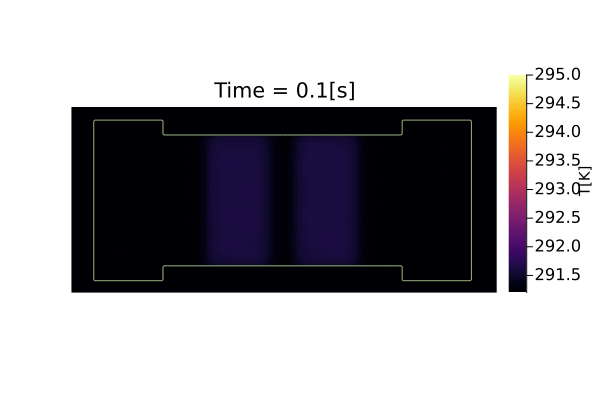

In [27]:
@gif for i in eachindex(SimuResult.tube_hist_t)
    plot(OHPTemp(),i,SimuResult,clim=(291.2,295.0))
    plot!(body,fillalpha=0)
end

Generate an animation of the liquid slug distribution over time with the immersed plate boundary overlaid.

[ Info: Saved animation to /var/folders/z7/8p7f62h924bf9b863dgvfs6m0000gn/T/jl_2nSJijQv6X.gif


Plots.AnimatedGif("/var/folders/z7/8p7f62h924bf9b863dgvfs6m0000gn/T/jl_2nSJijQv6X.gif")
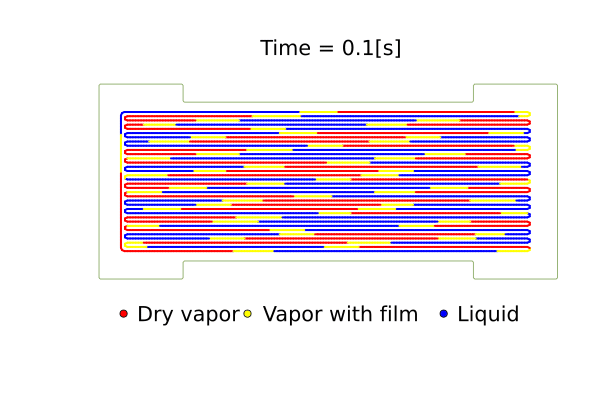

In [28]:
@gif for i in eachindex(SimuResult.tube_hist_t)
    plot(OHPSlug(),i,SimuResult,aspectratio=1)
    plot!(body,fillalpha=0)
end

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*